In [1]:
from util import *
from rich import print as rprint
plt.rcParams['font.family'] = 'Noto Sans'

%reload_ext autoreload
%autoreload 2

In [2]:
figPath = "../plots/control_designs/"

dirs = [a for a in getDirs(os.path.join(dataPath, 'control'), sstr='nVDCC') if "ISI_20" in a]
dirs.sort(key=natural_keys)
control_dirs = np.array(dirs)

## Get a list of designs in each category 
designs_in_categories = get_designs_in_categories(control_dirs)

for i,d in enumerate(control_dirs): print(i, d)

0 nVDCC_1_dVAZ_60_nAZ_33_RRP_55_ISI_20_nAP_10
1 nVDCC_1_dVAZ_60_nAZ_33_RRP_60_ISI_20_nAP_10
2 nVDCC_2_dVAZ_60_nAZ_7_RRP_60_ISI_20_nAP_10
3 nVDCC_2_dVAZ_60_nAZ_9_RRP_55_ISI_20_nAP_10
4 nVDCC_2_dVAZ_60_nAZ_9_RRP_60_ISI_20_nAP_10
5 nVDCC_2_dVAZ_60_nAZ_11_RRP_40_ISI_20_nAP_10
6 nVDCC_2_dVAZ_60_nAZ_11_RRP_45_ISI_20_nAP_10
7 nVDCC_2_dVAZ_60_nAZ_11_RRP_50_ISI_20_nAP_10
8 nVDCC_2_dVAZ_60_nAZ_13_RRP_35_ISI_20_nAP_10
9 nVDCC_2_dVAZ_60_nAZ_13_RRP_40_ISI_20_nAP_10
10 nVDCC_2_dVAZ_60_nAZ_13_RRP_45_ISI_20_nAP_10
11 nVDCC_2_dVAZ_60_nAZ_13_RRP_50_ISI_20_nAP_10
12 nVDCC_2_dVAZ_60_nAZ_15_RRP_30_ISI_20_nAP_10
13 nVDCC_2_dVAZ_60_nAZ_15_RRP_35_ISI_20_nAP_10
14 nVDCC_2_dVAZ_60_nAZ_17_RRP_30_ISI_20_nAP_10
15 nVDCC_2_dVAZ_60_nAZ_19_RRP_30_ISI_20_nAP_10
16 nVDCC_2_dVAZ_60_nAZ_21_RRP_20_ISI_20_nAP_10
17 nVDCC_2_dVAZ_60_nAZ_21_RRP_25_ISI_20_nAP_10
18 nVDCC_2_dVAZ_60_nAZ_23_RRP_20_ISI_20_nAP_10
19 nVDCC_2_dVAZ_60_nAZ_23_RRP_25_ISI_20_nAP_10
20 nVDCC_2_dVAZ_60_nAZ_25_RRP_20_ISI_20_nAP_10
21 nVDCC_2_dVAZ_60_nAZ_27_

### Load category info
Create category_info.pk file if it doesn't exist. Update it if needed

In [3]:
## If True, recreate category_info.pk. Override if category_info exists.
override = False

category_info_path = os.path.join(dataPath, 'control_eachCa/category_info.pk')
if os.path.exists(category_info_path) and not override:
    with open(category_info_path, "rb") as infile:
        category_info = pk.load(infile)
        
else:
    # get info (Pr, nRel, MVU, facilitation, Ca peak, residual Ca, syt) of each category
    category_info = np.empty([3,3,3,3], dtype=object)
    for nv, dv, naz, rrp in tq(list(product(range(3), repeat=4))):
        category_info[nv, dv, naz, rrp] = {'n_designs': len(designs_in_categories[nv, dv, naz, rrp])}

        # get representative designs (max and median facilitation)
        category_info[nv, dv, naz, rrp].update(get_rep_design(designs_in_categories[nv, dv, naz, rrp]))

        # Info related to vesicle release
        category_info[nv, dv, naz, rrp].update(get_release_info(designs_in_categories[nv, dv, naz, rrp]))

        # Calcium info
        category_info[nv, dv, naz, rrp].update(get_calcium_info(designs_in_categories[nv, dv, naz, rrp]))

        # Info about synaptotagmin
        category_info[nv, dv, naz, rrp].update(get_synaptotagmin_info(designs_in_categories[nv, dv, naz, rrp]))

        # Info about calcium overlap
        category_info[nv, dv, naz, rrp].update(get_ca_overlap_info(designs_in_categories[nv, dv, naz, rrp]))

    with open(category_info_path, "wb") as infile:
        pk.dump(category_info, infile)
    
    print(category_info[0,0,0,0].keys(), '\n\n', category_info[0,0,0,0])

## If True, update category_info.pk with new design info
update = False
if update:
    for nv, dv, naz, rrp in tq(list(product(range(3), repeat=4))):
        if len(designs_in_categories[nv, dv, naz, rrp]) >= 4:
            ...
            # Info about synaptotagmin
            # category_info[nv, dv, naz, rrp].update(get_synaptotagmin_info(designs_in_categories[nv, dv, naz, rrp]))

    with open(category_info_path, "wb") as infile:
        pk.dump(category_info, infile)

    print(category_info[0,0,0,0])
    print(category_info[2,2,2,1])

In [4]:
rprint(category_info[1,2,2,2])

{
    'n_designs': 34,
    'rep_design_max': np.str_('nVDCC_6_dVAZ_200_nAZ_35_RRP_50_ISI_20_nAP_10'),
    'rep_design_median': np.str_('nVDCC_6_dVAZ_200_nAZ_29_RRP_50_ISI_20_nAP_10'),
    'pr': (
        array([0.24797353, 0.61528824, 0.83561471, 0.93785882, 0.97483529,
       0.99003529, 0.99605   , 0.9981    , 0.99926471, 0.99952941]),
        array([0.02353632, 0.03718776, 0.03120082, 0.01861853, 0.00992442,
       0.00514318, 0.00260444, 0.0018031 , 0.00070955, 0.00054153])
    ),
    'rel': (
        array([0.28600882, 0.95198235, 1.81274412, 2.74143529, 3.68284118,
       4.60148235, 5.46346765, 6.30729706, 7.11386176, 7.89974706]),
        array([0.03224273, 0.10095943, 0.1770981 , 0.28186012, 0.37689018,
       0.48666174, 0.57055538, 0.70274575, 0.81319501, 0.90435444])
    ),
    'mvu': (
        array([1.151526  , 1.5430953 , 2.16464778, 2.9184905 , 3.77467688,
       4.64570799, 5.48404768, 6.31836711, 7.11872188, 7.90317516]),
        array([0.02564424, 0.07327315, 0.13547502, 0.24620164, 0.35291002,
       0.47140241, 0.56243144, 0.69586031, 0.81065964, 0.90234378])
    ),
    'facil': (
        array([1.        , 1.33956826, 1.87870983, 2.53202257, 3.27417399,
       4.02898093, 4.75621421, 5.47888093, 6.17253737, 6.8528875 ]),
        array([5.38537270e-17, 4.29486653e-02, 8.88297978e-02, 1.73503969e-01,
       2.51771745e-01, 3.38739654e-01, 4.09304410e-01, 5.09692047e-01,
       5.97171603e-01, 6.67438582e-01])
    ),
    'avg_ca_peak': (
        array([3.17997239, 3.30750261, 3.40259018, 3.48468683, 3.54540392,
       3.59508064, 3.63694705, 3.69455701, 3.72539654, 3.76752666]),
        array([0.18664346, 0.19041164, 0.19777544, 0.20855615, 0.21120641,
       0.20880977, 0.2144509 , 0.21926228, 0.21315793, 0.20239702])
    ),
    'avg_res_ca': (
        array([0.13956143, 0.17288323, 0.20157433, 0.22600633, 0.24771031,
       0.26808156, 0.28705863, 0.30558138, 0.32309403, 0.33970973]),
        array([0.00177894, 0.00302357, 0.00473771, 0.00589089, 0.00732196,
       0.00849476, 0.00921923, 0.01090728, 0.01202412, 0.01360223])
    ),
    'avg_ca_syt7_peak': (
        array([0.00732093, 0.02214783, 0.03545371, 0.04709957, 0.05715465,
       0.0656356 , 0.07282529, 0.07906637, 0.08440964, 0.08904802]),
        array([0.00036188, 0.00075692, 0.00110245, 0.00144013, 0.00174778,
       0.00198055, 0.00220465, 0.00238072, 0.0025191 , 0.00262214])
    ),
    'avg_ca_syt1_peak': (
        array([0.03886815, 0.04207752, 0.04457972, 0.04670547, 0.04836428,
       0.04992221, 0.05112798, 0.05252485, 0.05349708, 0.05453338]),
        array([0.00239927, 0.00268965, 0.00280492, 0.00307668, 0.00317496,
       0.00309405, 0.00320863, 0.00337388, 0.0033516 , 0.00321472])
    ),
    'rep_design_min': np.str_('nVDCC_6_dVAZ_200_nAZ_27_RRP_45_ISI_20_nAP_10'),
    'avg_peak_overlap': (
        array([0.46118472, 0.46805573, 0.47442805, 0.47780897, 0.48219835,
       0.48616766, 0.48900134, 0.49379153, 0.49290034, 0.49882205]),
        array([0.04474495, 0.04340579, 0.04454305, 0.04249971, 0.04257542,
       0.04155873, 0.04095738, 0.04213792, 0.03926819, 0.04021916])
    ),
    'avg_basal_overlap': (
        array([0.1866885 , 0.28194977, 0.34271708, 0.38617206, 0.41915504,
       0.44491147, 0.46552976, 0.48361856, 0.49967303, 0.51326392]),
        array([0.00702177, 0.00785694, 0.00821492, 0.0095692 , 0.00967865,
       0.00945742, 0.00991329, 0.01023443, 0.01046466, 0.01070123])
    )
}

In [5]:
for k in list(category_info[0,0,0,0]): print(k)

n_designs
rep_design_max
rep_design_median
pr
rel
mvu
facil
avg_ca_peak
avg_res_ca
avg_ca_syt7_peak
avg_ca_syt1_peak
rep_design_min
avg_peak_overlap
avg_basal_overlap


In [ ]:
figsize_4d = (5,4.1)

ticklabelsize_4d = 8
labelsize_4d = 10
sublabelsize_4d = 8
textsize_4d = 8

cases = ['Low', 'Mid', 'High']

marker = ['-','--']

### Representative plots (lineplots)

In [61]:
title_text = {
    'pr': 'Release probability', 
    'rel': 'Vesicle releases',
    # 'mvu': 'Multi-vesicle usage',
    'facil': 'Facilitation',
    'avg_peak_overlap': '% [Ca] overlap at peak',
    'avg_basal_overlap': '% overlap in residual [Ca]',
    'avg_ca_peak': r'Peak [Ca] ($\mu$M)', 
    'avg_res_ca': r'Residual [Ca] ($\mu$M)',
    'avg_ca_syt7_peak': '% Ca-bound syt-7',
    'avg_ca_syt1_peak': '% Ca-bound syt-1'
}
keys = list(title_text.keys())

y_data = {}
for nv, dv, naz, rrp in product(range(3), repeat=4):
    try:
        design = category_info[nv, dv, naz, rrp]['rep_design_median']
    except KeyError:
        continue

    ## Get Pr data
    data_pr = pd.read_csv(os.path.join(dataPath, 'control', design, 'result.dat'),
                       usecols=['Pr', 'Rel'], sep='\t')
    
    ## Get overlap data
    avg_peak_overlap, avg_basal_overlap = get_ca_overlap(design)

    ## Get calcium data
    ## Read data from 'CaConc.dat' of the design
    data = pd.read_csv(os.path.join(dataPath, 'control', design, 'CaConc.dat'), sep='\t',
                        usecols=range(int(getSimInfo(design, 'nAZ', skip=0))+1))
    data['mean'] = np.mean(data.iloc[:,1:], axis=1)
    # print(design, '\n', data)
    
    ## Detect peaks and ensure all 10 peaks are detected
    idx = detect_peaks(data['mean'], mph=1, mpd=200, threshold=0, edge='rising', show=False)
    assert len(idx) == 10, f'Peak detecction failed for design {design}'

    ca_peak = [data.loc[id,'mean'] for id in idx]
    ca_res = [np.mean(data.loc[id+100:id+300,'mean']) for id in idx]

    ca_syt7_peak, ca_syt1_peak = get_ca_syt(design)

    label=f'{cdiv[nv]},  {cdiv[dv]},  {cdiv[naz]},  {cdiv[rrp]}'
    y_data[label] = {
        'pr': data_pr['Pr'], 
        'rel': data_pr['Rel'], 
        'mvu': data_pr['Rel']/data_pr['Pr'], 
        'facil': data_pr['Rel']*data_pr['Pr'][0]/data_pr['Pr']/data_pr['Rel'][0],
        'avg_peak_overlap': avg_peak_overlap, 
        'avg_basal_overlap': avg_basal_overlap,
        'avg_ca_peak': ca_peak, 
        'avg_res_ca': ca_res,
        'avg_ca_syt7_peak': ca_syt7_peak,
        'avg_ca_syt1_peak': ca_syt1_peak
    }

    
y_sorted = [list(y['facil']) for y in y_data.values()]
y_sorted.sort(key = lambda x: x[-1], reverse=True)
# print(y_sorted)

des_sorted = []
for yy in y_sorted:
    des_sorted.append([k for k, v in y_data.items() if list(v['facil']) == yy][0])


In [57]:
titlesize_lp = 11
ticklabelsize_lp = 9
labelsize_lp = 10
legendsize_lp = 7
textsize_lp = 7

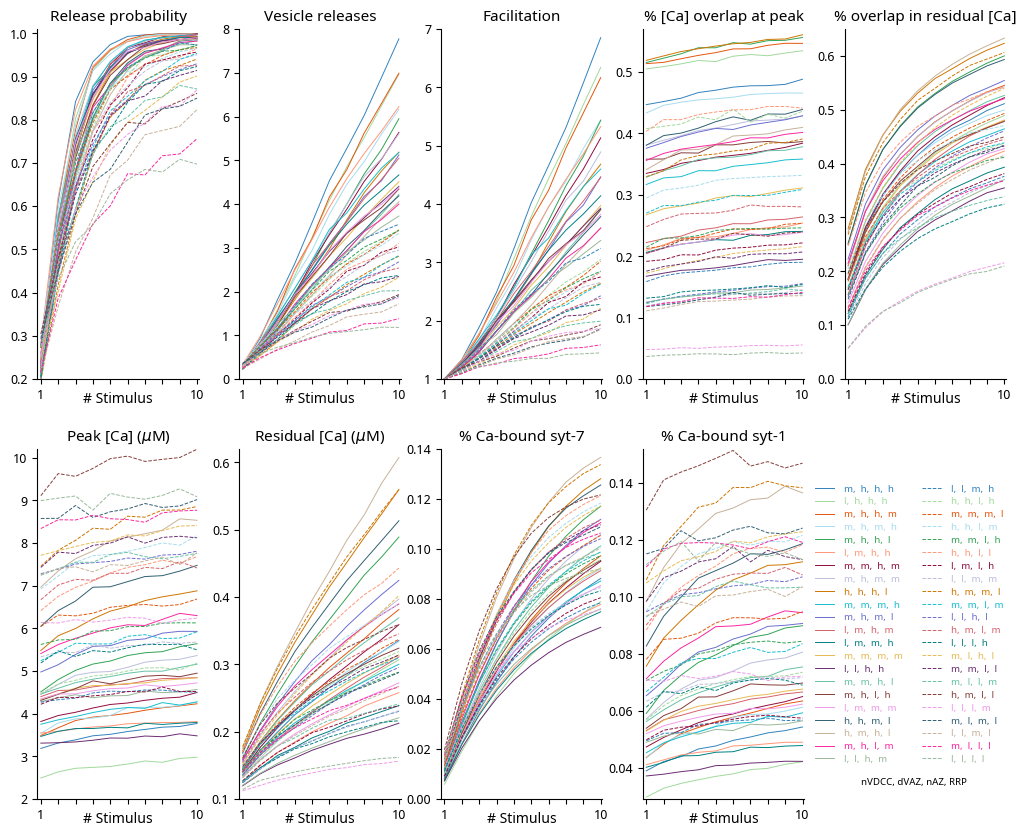

In [62]:
fig, ax = plt.subplots(2,5, sharex=False, figsize=(12.5,10))
fig.subplots_adjust(hspace=0.2, wspace=0.25)
for i, key in enumerate(keys):
    y_sorted = [list(y_data[des][key]) for des in des_sorted]
    x = list(range(1,11))
    for j,y in enumerate(y_sorted):
        # print(y)
        # label = [k for k, v in y_data.items() if list(v) == list(y)][0]
        ax[i//5,i%5].plot(x, y, label=des_sorted[j],
                   # marker='.', markersize=4,
                   linestyle=marker[j//22],
                   linewidth=0.7, color=cpall[j%22])

    ax[i//5,i%5].set_xlim(0.8,10.1)
    ax[i//5,i%5].spines[['right', 'top']].set_visible(False)

    ax[i//5,i%5].set_title(title_text[key], fontsize=titlesize_lp)
    # ax[i//5,i%5].set_xticks([1,4,7,10], [1,4,7,10], fontsize=ticklabelsize_lp)
    ax[i//5,i%5].set_xticks(range(1,11), [1]+['']*8+[10])#, fontsize=ticklabelsize_lp)
    ax[i//5,i%5].tick_params(axis='both', labelsize=ticklabelsize_lp)
    ax[i//5,i%5].set_xlabel('# Stimulus', labelpad=-7, fontsize=labelsize_lp)

ax[-1,-2].legend(frameon=False, loc='center left', bbox_to_anchor=(1.01, 0.5), 
              fontsize=legendsize_lp, handletextpad=1, handlelength=2, ncol=2,
              labelspacing=0.4, labelcolor='linecolor')

ax[-1,-1].text(0.1, 0.04, 'nVDCC, dVAZ, nAZ, RRP', size=textsize_lp, color=cpdark[-1])

ax[0,0].set_ylim(0.2,1.01)
ax[0,1].set_ylim(0,8)
ax[0,2].set_ylim(1,7)
ax[0,3].set_ylim(0,0.57)
ax[0,4].set_ylim(0,0.65)
ax[1,0].set_ylim(2,10.2)
ax[1,1].set_ylim(0.1,0.62)
ax[1,2].set_ylim(0,0.14)
ax[1,3].set_ylim(0.029,0.152)
ax[-1,-1].axis('off')

plt.show()
# fig.savefig(os.path.join(figPath, 'rep_plots.svg'), dpi=300, 
#             bbox_inches='tight', transparent=True)